# Electricity Load Forecasting: Linear Regression Baseline

In this notebook, we load our preprocessed time-series data and train a Linear Regression model. This will serve as our baseline to establish how well standard autoregressive features (lags and rolling means) predict future electricity consumption.

## 1. Imports
We import pandas for data handling, and scikit-learn for our model, metrics, and data splitting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Data Loading and Client Selection
We load the highly compressed Parquet file. To evaluate the model clearly and avoid overwhelming system memory during this baseline test, we will filter the dataset to isolate a single client.

In [7]:
print("Loading processed data...")
df_long = pd.read_parquet('processed_electricity_data.parquet')

# Select a specific client for modeling
client_id = 'MT_250'
print(f"Filtering data for client: {client_id}")
df_client = df_long[df_long['ClientID'] == client_id].copy()

Loading processed data...
Filtering data for client: MT_250


## 3. Data Preparation and Encoding
Machine learning models require numerical inputs. We convert our boolean holiday/weekend flags to integers (0 and 1). Furthermore, cyclical categorical variables like 'Hour' and 'Weekday' must be One-Hot Encoded so the model doesn't assume that Hour 2 is twice as large as Hour 1.

In [8]:
# Convert booleans to integers
df_client['Is_Weekend'] = df_client['Is_Weekend'].astype(int)
df_client['Is_Holiday'] = df_client['Is_Holiday'].astype(int)

# One-Hot Encoding for categorical time variables
df_model = pd.get_dummies(df_client, columns=['Hour', 'Weekday'], drop_first=True)

## 4. Chronological Train/Test Split


When working with time-series data, we can **never** randomly shuffle and split our data. We must respect the flow of time to prevent "data leakage" (peeking into the future to predict the past). We will use data prior to 2014 for training, and data from 2014 onwards for testing.

In [9]:
cutoff_date = '2014-01-01'

train = df_model[df_model['Date'] < cutoff_date]
test = df_model[df_model['Date'] >= cutoff_date]

# Define features (X) and target (y)
cols_to_drop = ['Date', 'ClientID', 'DayMonth', 'Consumption']

X_train = train.drop(columns=cols_to_drop)
y_train = train['Consumption']

X_test = test.drop(columns=cols_to_drop)
y_test = test['Consumption']

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (105119, 34)
Testing shape: (35041, 34)


## 5. Model Training and Evaluation
We train the Linear Regression model on our historical data. We evaluate its performance using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to understand our average prediction error in kilowatts (kW).

In [10]:
print("Training Linear Regression model...")
model = LinearRegression()
model.fit(X_train, y_train)

print("Making predictions on test set...")
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- Results for {client_id} ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} kW")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} kW")

Training Linear Regression model...
Making predictions on test set...

--- Results for MT_250 ---
Mean Absolute Error (MAE): 4.06 kW
Root Mean Squared Error (RMSE): 5.61 kW


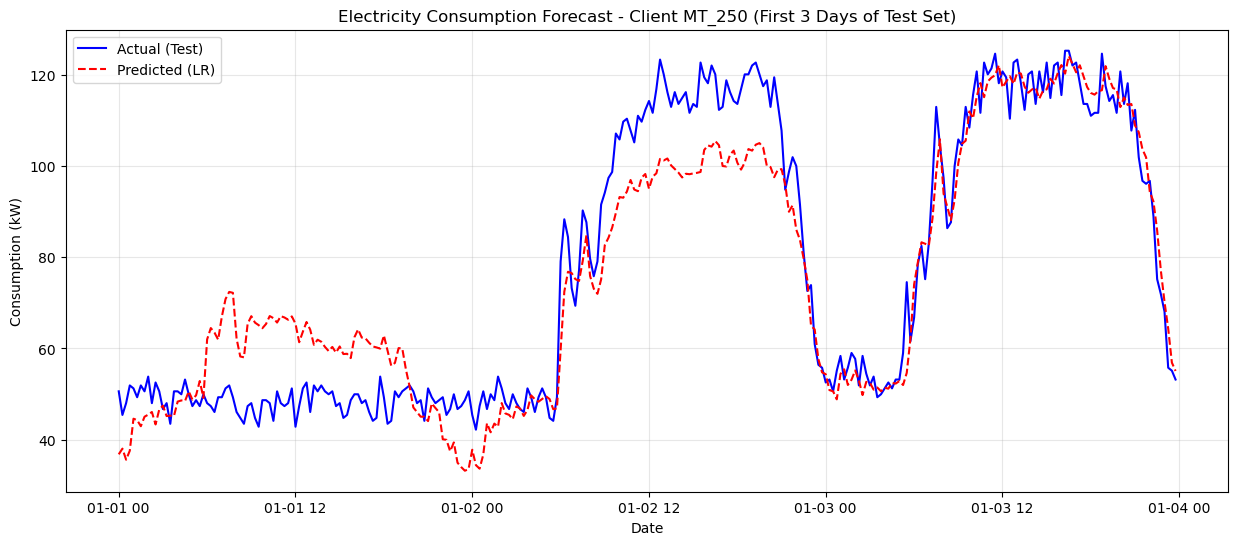

In [11]:
days_to_plot = 288 

plt.figure(figsize=(15, 6))
plt.plot(test['Date'].iloc[:days_to_plot], y_test.iloc[:days_to_plot], label='Actual (Test)', color='blue')
plt.plot(test['Date'].iloc[:days_to_plot], y_pred[:days_to_plot], label='Predicted (LR)', color='red', linestyle='--')
plt.title(f'Electricity Consumption Forecast - Client {client_id} (First 3 Days of Test Set)')
plt.xlabel('Date')
plt.ylabel('Consumption (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()